# Seeded (batch-elimination) audit graphs: Victoria 2025

The 2025 Victorian Senate election is the largest STV election in the
world (65 candidates, 6 seats, N = 4,101,762). A full plausible DFS
graph is computationally intractable at any useful margin, because the
early layers explode combinatorially over the many weak candidates.
**Batch elimination** (writeup §2.3) abridges those layers: it
rigorously justifies eliminating a designated weak set simultaneously,
and seeds the DFS from the surviving configurations.

This notebook builds the seeded graph at the results-table margin
M = 20,000, plots it, and runs both audit drivers. Note the timescales:
construction takes minutes, and each audit pass is dominated by the
sample size, not the graph.


In [1]:
# Make the repo root importable when the kernel cwd is notebooks/.
import os, sys

repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)


## 1. Load the profile


In [2]:
from src.election_graphs.numpy_profile import load_numpy

profile, m, *_ = load_numpy(
    os.path.join(repo_root, "data", "australia_federal", "vic_2025_votekit.csv")
)
print(f"C = {len(profile.candidates)} candidates, m = {m} seats, "
      f"N = {round(profile.total_ballot_wt)} ballots")


C = 65 candidates, m = 6 seats, N = 4101762 ballots


## 2. Seeded construction

`seeded_build` partitions the candidates into very-strong / strong / weak
sets from their maximum possible tallies (it prints the partition), seats
any forced very-strong winners, allocates one seed vertex per plausible
configuration of the strong candidates, and only then runs the DFS.
The resulting graph is a few hundred vertices instead of an intractable
full DFS — and audits of it target the same reported outcome at the same
margin, so nothing is lost.


In [3]:
from src.wigm_graphs.seeded import SeededWIGMGraphConstructor

constructor = SeededWIGMGraphConstructor(
    profile,
    m=m,
    MoI=20_000,
    memory_lite=True,
    simultaneous=True,
)
constructor.seeded_build()
constructor.add_natural_edges()
constructor.assign_tightest_margins()
constructor.coherence_check()


[seeded_build:initialized] vertices=0, edges=0, stack=0, runtime_caches=0, rss=5474.3 MiB; profile=98.3 MiB, stencils=5142.1 MiB, caches=0.0 MiB, edge_weights=0.0 MiB, tallies=0.0 MiB; memory_lite=True, candidates=65, ballots=1256848
[seeded_build:pre-seating complete] vertices=3, edges=4, stack=0, runtime_caches=0, rss=5522.6 MiB; profile=98.3 MiB, stencils=5142.1 MiB, caches=0.0 MiB, edge_weights=38.4 MiB, tallies=0.0 MiB; already_elected=4, remaining_seats=2


[seeded_build:candidate partition complete] vertices=3, edges=4, stack=0, runtime_caches=0, rss=5522.8 MiB; profile=98.3 MiB, stencils=5142.1 MiB, caches=0.0 MiB, edge_weights=38.4 MiB, tallies=0.0 MiB; strong=9, weak=44
[seeded_build:allocating seeds] vertices=3, edges=4, stack=0, runtime_caches=0, rss=5522.8 MiB; profile=98.3 MiB, stencils=5142.1 MiB, caches=0.0 MiB, edge_weights=38.4 MiB, tallies=0.0 MiB; flexible=8, expected_viable_seeds=256
[seeded_build:seed allocation complete] vertices=259, edges=4, stack=256, runtime_caches=0, rss=5522.8 MiB; profile=98.3 MiB, stencils=5142.1 MiB, caches=0.0 MiB, edge_weights=38.4 MiB, tallies=0.0 MiB; created=256


[seeded_build:construction complete] vertices=427, edges=659, stack=0, runtime_caches=0, rss=5792.9 MiB; profile=98.3 MiB, stencils=5142.1 MiB, caches=0.0 MiB, edge_weights=287.7 MiB, tallies=0.2 MiB; expanded=411
Coherence check passed.
  terminal vertices: 13
  winner set: ['PATERSON James', 'HUME Jane', 'CICCONE Raffaele', 'WALSH Jess', 'ANANDA-RAJAH Michelle', 'HODGINS-MAY Steph']


True

## 3. Plot it

The black connector on the left marks the pre-seated very-strong
winners; each seed vertex continues one plausible configuration of the
strong candidates.


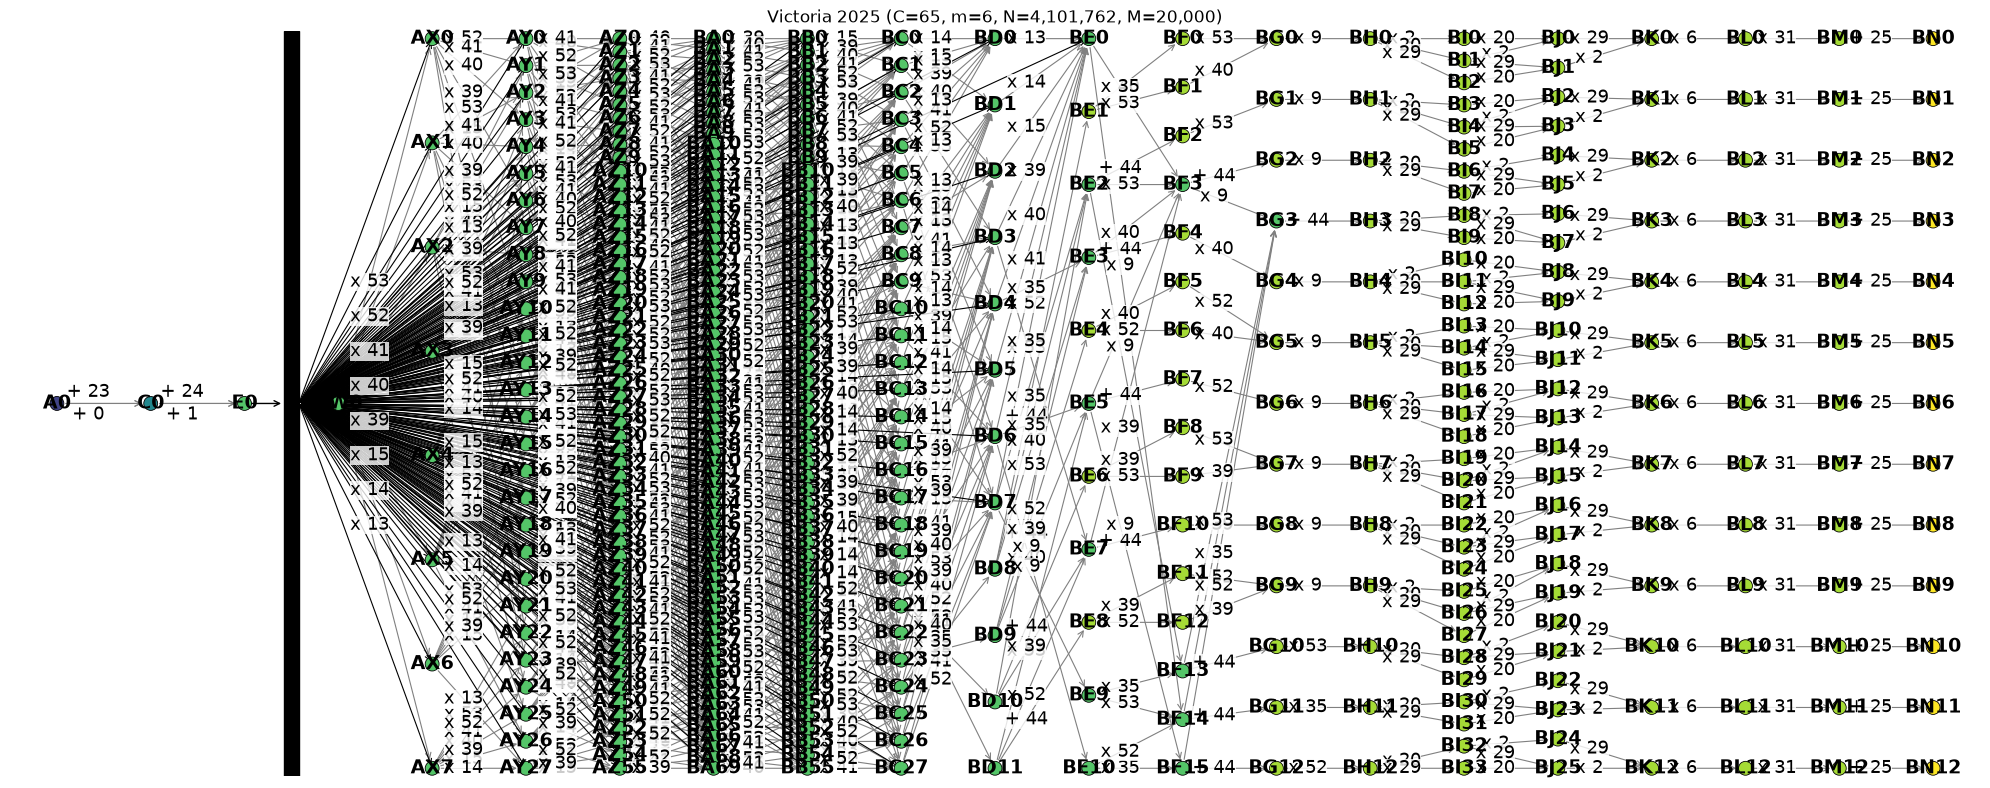

In [4]:
from src.plotting import plot_wigm_graph

plot_wigm_graph(
    constructor,
    figsize=(20, 8),
    node_size=100,
    font_size=14,
    label_edges="minimal",
    label_vertices=True,
    plot_horizontal=True,
    title="Victoria 2025 (C=65, m=6, N=4,101,762, M=20,000)",
)


## 4. Delta-method audit

One seeded trial at the certifying sample size from the results table
(0.5% of ballots, 20,508 of them). This is the audit that makes
Victoria's row: the Delta method certifies at half a percent of the
ballots cast.


In [5]:
from src.test_processes.delta_method import DeltaMethodAuditDriver

delta_driver = DeltaMethodAuditDriver(
    constructor,
    fractional_sample_size=1 / 200,
    noise_level=0.02,
    seed=0,
    alpha=0.05,
    verbose=True,
)
success = delta_driver.run()
print(f"certified: {success} with a sample of {delta_driver.sample_size} ballots")


Starting Delta-Method audit: 6833 escape edges, 400 vertices, n=20508, alpha=0.05, alpha_K=0.005, source=implicit sampler, seeded=True.
Layer 0 (1/18): 1 escape edges across 1 vertices.
  Vertex A0: 1 escape edges.
    [1/1; vertex 1/1; overall 1/6833] A0-E23 PASS: escape=ELIMINATE CICCONE Raffaele(23); assert CICCONE Raffaele > quota; CI=[810,808.41, inf), estimate=813,156.91, recorded=815,557.00, SE=1,385.22, discrepancies=12, K<=4821.
Layer 2 (2/18): 1 escape edges across 1 vertices.
  Vertex C0: 1 escape edges.
    [1/1; vertex 1/1; overall 2/6833] C0-E24 PASS: escape=ELIMINATE WALSH Jess(24); assert WALSH Jess > quota; CI=[223,937.01, inf), estimate=228,842.91, recorded=231,587.12, SE=2,893.66, discrepancies=34, K<=10408.
Layer 48 (3/18): 26 escape edges across 1 vertices.
  Vertex AW0: 26 escape edges.
    [1/26; vertex 1/26; overall 3/6833] AW0-E2 PASS: escape=ELIMINATE HOPPITT Kyle(2); assert HOPPITT Kyle > EL ACHKAR Rasheed; CI=[103,968.30, inf), estimate=115,557.15, recorded=

    [2/672; vertex 2/24; overall 230/6833] AY0-W2 PASS: escape=ELECT HOPPITT Kyle(2); assert quota > HOPPITT Kyle; CI=[450,699.46, inf), estimate=462,289.52, recorded=462,141.12, SE=6,836.19, discrepancies=41, K<=12097.
    [3/672; vertex 3/24; overall 231/6833] AY0-E6 PASS: escape=ELIMINATE PATTEN Fiona(6); assert PATTEN Fiona > EL ACHKAR Rasheed; CI=[162,322.36, inf), estimate=167,405.43, recorded=167,811.51, SE=2,998.16, discrepancies=40, K<=11857.
    [4/672; vertex 4/24; overall 232/6833] AY0-W6 PASS: escape=ELECT PATTEN Fiona(6); assert quota > PATTEN Fiona; CI=[412,754.43, inf), estimate=417,837.49, recorded=417,631.04, SE=2,998.15, discrepancies=40, K<=11857.
    [5/672; vertex 5/24; overall 233/6833] AY0-E9 PASS: escape=ELIMINATE JEGES Helen(9); assert JEGES Helen > EL ACHKAR Rasheed; CI=[70,895.18, inf), estimate=76,029.42, recorded=75,600.21, SE=3,028.34, discrepancies=41, K<=12097.
    [6/672; vertex 6/24; overall 234/6833] AY0-W9 PASS: escape=ELECT JEGES Helen(9); assert q

    [252/672; vertex 12/24; overall 480/6833] AY10-W25 PASS: escape=ELECT ANANDA-RAJAH Michelle(25); assert quota > ANANDA-RAJAH Michelle; CI=[320,230.29, inf), estimate=328,823.73, recorded=328,603.05, SE=5,068.69, discrepancies=44, K<=12814.
    [253/672; vertex 13/24; overall 481/6833] AY10-E29 PASS: escape=ELIMINATE FINN Bernie(29); assert FINN Bernie > CLONARIDIS Nick; CI=[75,388.12, inf), estimate=80,622.80, recorded=81,145.44, SE=3,087.58, discrepancies=43, K<=12575.
    [254/672; vertex 14/24; overall 482/6833] AY10-W29 PASS: escape=ELECT FINN Bernie(29); assert quota > FINN Bernie; CI=[499,206.13, inf), estimate=504,340.36, recorded=504,217.46, SE=3,028.33, discrepancies=41, K<=12097.
    [255/672; vertex 15/24; overall 483/6833] AY10-E31 PASS: escape=ELIMINATE PICKERING Warren(31); assert PICKERING Warren > CLONARIDIS Nick; CI=[180,247.03, inf), estimate=185,352.52, recorded=185,939.89, SE=3,011.39, discrepancies=40, K<=11857.
    [256/672; vertex 16/24; overall 484/6833] AY1

    [494/672; vertex 14/24; overall 722/6833] AY20-E31 PASS: escape=ELIMINATE PICKERING Warren(31); assert PICKERING Warren > CLONARIDIS Nick; CI=[180,275.07, inf), estimate=185,380.57, recorded=185,967.99, SE=3,011.39, discrepancies=40, K<=11857.
    [495/672; vertex 15/24; overall 723/6833] AY20-W31 PASS: escape=ELECT PICKERING Warren(31); assert quota > PICKERING Warren; CI=[394,552.82, inf), estimate=399,584.16, recorded=399,396.42, SE=2,967.64, discrepancies=39, K<=11617.
    [496/672; vertex 16/24; overall 724/6833] AY20-E35 PASS: escape=ELIMINATE VAN DEN LAMB Jordan(35); assert VAN DEN LAMB Jordan > CLONARIDIS Nick; CI=[63,402.99, inf), estimate=68,486.02, recorded=69,086.55, SE=2,998.13, discrepancies=40, K<=11857.
    [497/672; vertex 17/24; overall 725/6833] AY20-W35 PASS: escape=ELECT VAN DEN LAMB Jordan(35); assert quota > VAN DEN LAMB Jordan; CI=[511,499.85, inf), estimate=516,478.71, recorded=516,277.85, SE=2,936.69, discrepancies=38, K<=11376.
    [498/672; vertex 18/24;

    [70/1288; vertex 1/23; overall 970/6833] AZ3-E2 PASS: escape=ELIMINATE HOPPITT Kyle(2); assert HOPPITT Kyle > EL ACHKAR Rasheed; CI=[106,981.50, inf), estimate=118,689.20, recorded=118,837.24, SE=6,905.58, discrepancies=42, K<=12336.
    [71/1288; vertex 2/23; overall 971/6833] AZ3-W2 PASS: escape=ELECT HOPPITT Kyle(2); assert quota > HOPPITT Kyle; CI=[454,840.98, inf), estimate=466,549.65, recorded=466,601.24, SE=6,906.15, discrepancies=42, K<=12336.
    [72/1288; vertex 3/23; overall 972/6833] AZ3-E6 PASS: escape=ELIMINATE PATTEN Fiona(6); assert PATTEN Fiona > EL ACHKAR Rasheed; CI=[155,224.14, inf), estimate=160,307.21, recorded=160,713.29, SE=2,998.16, discrepancies=40, K<=11857.
    [73/1288; vertex 4/23; overall 973/6833] AZ3-W6 PASS: escape=ELECT PATTEN Fiona(6); assert quota > PATTEN Fiona; CI=[419,848.57, inf), estimate=424,931.64, recorded=424,725.19, SE=2,998.15, discrepancies=40, K<=11857.
    [74/1288; vertex 5/23; overall 974/6833] AZ3-E9 PASS: escape=ELIMINATE JEGES

...

    [93/259; vertex 2/8; overall 6389/6833] BI12-W2 PASS: escape=ELECT HOPPITT Kyle(2); assert quota > HOPPITT Kyle; CI=[398,693.05, inf), estimate=415,850.87, recorded=416,077.94, SE=10,120.23, discrepancies=50, K<=14235.
    [94/259; vertex 3/8; overall 6390/6833] BI12-E6 PASS: escape=ELIMINATE PATTEN Fiona(6); assert PATTEN Fiona > UNKLES James William; CI=[79,135.02, inf), estimate=85,248.40, recorded=85,737.27, SE=3,605.87, discrepancies=54, K<=15176.
    [95/259; vertex 4/8; overall 6391/6833] BI12-W6 PASS: escape=ELECT PATTEN Fiona(6); assert quota > PATTEN Fiona; CI=[350,292.23, inf), estimate=356,184.71, recorded=356,152.82, SE=3,475.57, discrepancies=49, K<=13999.
    [96/259; vertex 5/8; overall 6392/6833] BI12-W20 PASS: escape=ELECT UNKLES James William(20); assert quota > UNKLES James William; CI=[436,002.04, inf), estimate=441,433.11, recorded=441,890.09, SE=3,203.42, discrepancies=47, K<=13526.
    [97/259; vertex 6/8; overall 6393/6833] BI12-E25 PASS: escape=ELIMINATE A

    [25/156; vertex 1/6; overall 6580/6833] BJ4-E6 PASS: escape=ELIMINATE PATTEN Fiona(6); assert PATTEN Fiona > FINN Bernie; CI=[46,942.28, inf), estimate=54,490.12, recorded=53,406.03, SE=4,451.96, discrepancies=52, K<=14706.
    [26/156; vertex 2/6; overall 6581/6833] BJ4-W6 PASS: escape=ELECT PATTEN Fiona(6); assert quota > PATTEN Fiona; CI=[323,450.18, inf), estimate=329,741.63, recorded=330,593.00, SE=3,710.90, discrepancies=48, K<=13763.
    [27/156; vertex 3/6; overall 6582/6833] BJ4-E25 PASS: escape=ELIMINATE ANANDA-RAJAH Michelle(25); assert ANANDA-RAJAH Michelle > FINN Bernie; CI=[142,236.68, inf), estimate=154,688.30, recorded=154,460.09, SE=7,344.37, discrepancies=53, K<=14941.
    [28/156; vertex 4/6; overall 6583/6833] BJ4-W29 PASS: escape=ELECT FINN Bernie(29); assert quota > FINN Bernie; CI=[375,520.65, inf), estimate=384,231.75, recorded=383,999.04, SE=5,138.08, discrepancies=46, K<=13289.
    [29/156; vertex 5/6; overall 6584/6833] BJ4-E31 PASS: escape=ELIMINATE PICK

    [1/26; vertex 1/2; overall 6764/6833] BL0-E25 PASS: escape=ELIMINATE ANANDA-RAJAH Michelle(25); assert ANANDA-RAJAH Michelle > PICKERING Warren; CI=[12,399.16, inf), estimate=25,959.92, recorded=25,289.41, SE=7,998.57, discrepancies=53, K<=14941.
    [2/26; vertex 2/2; overall 6765/6833] BL0-W31 PASS: escape=ELECT PICKERING Warren(31); assert quota > PICKERING Warren; CI=[95,491.40, inf), estimate=106,719.62, recorded=105,781.38, SE=6,622.76, discrepancies=47, K<=13526.
  Vertex BL1: 2 escape edges.
    [3/26; vertex 1/2; overall 6766/6833] BL1-E25 PASS: escape=ELIMINATE ANANDA-RAJAH Michelle(25); assert ANANDA-RAJAH Michelle > PICKERING Warren; CI=[15,704.94, inf), estimate=29,225.79, recorded=28,556.28, SE=7,975.03, discrepancies=53, K<=14941.
    [4/26; vertex 2/2; overall 6767/6833] BL1-W31 PASS: escape=ELECT PICKERING Warren(31); assert quota > PICKERING Warren; CI=[96,383.62, inf), estimate=107,613.78, recorded=106,676.92, SE=6,623.91, discrepancies=47, K<=13526.
  Vertex BL2

    [184/214; vertex 30/60; overall 6803/6833] BE0-M22 PASS: escape=ELIMINATE McKAY Roger Ivan(22); assert VAN DEN LAMB Jordan > McKAY Roger Ivan mentions; CI=[55,496.72, inf), estimate=60,475.58, recorded=61,183.34, SE=2,936.69, discrepancies=38, K<=11376.
    [185/214; vertex 31/60; overall 6804/6833] BE0-M26 PASS: escape=ELIMINATE PSAILA Lynn(26); assert VAN DEN LAMB Jordan > PSAILA Lynn mentions; CI=[50,049.44, inf), estimate=55,382.23, recorded=56,005.99, SE=3,145.46, discrepancies=45, K<=13051.
    [186/214; vertex 32/60; overall 6805/6833] BE0-M27 PASS: escape=ELIMINATE KELLEY Stephenie(27); assert VAN DEN LAMB Jordan > KELLEY Stephenie mentions; CI=[47,878.26, inf), estimate=53,211.07, recorded=53,633.62, SE=3,145.46, discrepancies=45, K<=13051.
    [187/214; vertex 33/60; overall 6806/6833] BE0-M28 PASS: escape=ELIMINATE BAKER David(28); assert VAN DEN LAMB Jordan > BAKER David mentions; CI=[48,590.68, inf), estimate=53,923.38, recorded=54,947.49, SE=3,145.40, discrepancies=45

    [200/214; vertex 46/60; overall 6819/6833] BE0-M48 PASS: escape=ELIMINATE HENDERSON Brittney(48); assert VAN DEN LAMB Jordan > HENDERSON Brittney mentions; CI=[50,600.24, inf), estimate=55,683.27, recorded=56,098.64, SE=2,998.13, discrepancies=40, K<=11857.
    [201/214; vertex 47/60; overall 6820/6833] BE0-M49 PASS: escape=ELIMINATE YAWARI Nasser(49); assert VAN DEN LAMB Jordan > YAWARI Nasser mentions; CI=[50,539.96, inf), estimate=55,674.17, recorded=56,122.72, SE=3,028.32, discrepancies=41, K<=12097.
    [202/214; vertex 48/60; overall 6821/6833] BE0-M50 PASS: escape=ELIMINATE BARWICK Robert(50); assert VAN DEN LAMB Jordan > BARWICK Robert mentions; CI=[38,275.71, inf), estimate=43,254.57, recorded=43,454.07, SE=2,936.69, discrepancies=38, K<=11376.
    [203/214; vertex 49/60; overall 6822/6833] BE0-M51 PASS: escape=ELIMINATE YOHANNA Sleiman(51); assert VAN DEN LAMB Jordan > YOHANNA Sleiman mentions; CI=[38,461.15, inf), estimate=43,492.47, recorded=43,892.18, SE=2,967.63, disc

## 5. Mismatch-based audit

At the 2% artificial noise level of the results table, the mismatch
audit does **not** certify Victoria (its ASN column is an X): the
diluted margin M/N = 0.5% is small relative to the mismatch rate. To
demonstrate the driver without sampling to the N/2 cap, we bound the
sample at 20,000 ballots and watch how many escape-edge compilers
certify.


In [6]:
from src.test_processes.driver import GlobalAuditDriver

mismatch_driver = GlobalAuditDriver(
    constructor,
    noise_level=0.02,
    sample_size=20_000,
    seed=0,
    compiler_type="noise",
    simultaneous=True,
    alpha=0.05,
    print_diagnostics_every=2_000,
)
print(f"escape-edge compilers: {len(mismatch_driver.compilers)}")

certified = mismatch_driver.run(constructor.ballot_matrix)
print(
    f"certified: {certified} — "
    f"{len(mismatch_driver.certified)}/{len(mismatch_driver.compilers)} "
    f"compilers passed after {mismatch_driver.i} ballots"
)


Detected seeded audit graph.
  very strong: ['PATERSON James', 'HUME Jane', 'CICCONE Raffaele', 'WALSH Jess']
  strong: ['HOPPITT Kyle', 'PATTEN Fiona', 'JEGES Helen', 'UNKLES James William', 'ANANDA-RAJAH Michelle', 'FINN Bernie', 'PICKERING Warren', 'VAN DEN LAMB Jordan', 'HODGINS-MAY Steph']
  weak: ['ARNOLD Glenn', 'MIRABELLA Greg', 'KMETJ Chrestyna', 'DAVY Alice', 'EVANS Shea', 'McMILLAN Benjamin', 'AUSTIN-ABDULLAH Racquel', 'AL-SAIMARY Laylah', 'CORDNER HUNT Kammy', 'GNIESLAW Simon Mark Simcha', 'VONGVIXAY Keo', 'HERNAN Taylor', 'JEAN Ron', 'McKAY Roger Ivan', 'PSAILA Lynn', 'KELLEY Stephenie', 'BAKER David', 'FOREMAN Jane', 'BRADBURY Christopher', 'McKENZIE Heath', 'NOBLE Carly', 'PRICE Steph', 'ACKERLY Celeste', 'JESSUP Bert', 'FORD Matthew', 'MATULEC Stephen', 'ARI Navera', 'IAMPOLSKI Rachel', 'SLATER Maddie', 'HENDERSON Brittney', 'YAWARI Nasser', 'BARWICK Robert', 'YOHANNA Sleiman', 'SAINI Raj', 'ALLE Kirti', 'KANAKAGIRI Yashaswini Srinivas', 'CHEUNG Heena Sinha', 'ABEYSINGH

Removed 153 duplicate compilers.
escape-edge compilers: 7104


Audit diagnostic after 2000 samples: 225 compilers remain below threshold (6879/7104 certified).
  BL9-E25: M=0.199453, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12505.99937147036, kind=CobraNoiseFilterCompiler
  BL7-E25: M=0.202329, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12567.71975387985, kind=CobraNoiseFilterCompiler
  BL5-E25: M=0.20296, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12581.129325789458, kind=CobraNoiseFilterCompiler
  BL0-E25: M=0.205975, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12644.706125222874, kind=CobraNoiseFilterCompiler
  BL8-E25: M=0.270127, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=13813.602604195097, kind=CobraNoiseFilterCompiler


Audit diagnostic after 4000 samples: 54 compilers remain below threshold (7050/7104 certified).
  BL9-E25: M=0.997783, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12505.99937147036, kind=CobraNoiseFilterCompiler
  BL7-E25: M=1.02677, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12567.71975387985, kind=CobraNoiseFilterCompiler
  BL5-E25: M=1.03317, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12581.129325789458, kind=CobraNoiseFilterCompiler
  BL0-E25: M=1.0641, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12644.706125222874, kind=CobraNoiseFilterCompiler
  BL8-E25: M=1.83023, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=13813.602604195097, kind=CobraNoiseFilterCompiler


Audit diagnostic after 6000 samples: 40 compilers remain below threshold (7064/7104 certified).
  BL9-E25: M=0.199011, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12505.99937147036, kind=CobraNoiseFilterCompiler
  BL7-E25: M=0.207745, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12567.71975387985, kind=CobraNoiseFilterCompiler
  BL5-E25: M=0.209692, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12581.129325789458, kind=CobraNoiseFilterCompiler
  BL0-E25: M=0.219177, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12644.706125222874, kind=CobraNoiseFilterCompiler
  BG2-E29: M=0.366049, escape=ELIMINATE 29:FINN Bernie, margin=10603.285661456597, kind=CobraNoiseFilterCompiler


...

Audit diagnostic after 12000 samples: 40 compilers remain below threshold (7064/7104 certified).
  BH2-E2: M=0.059346, escape=ELIMINATE 2:HOPPITT Kyle, margin=10017.95344362886, kind=CobraNoiseFilterCompiler
  BG2-E29: M=0.0703417, escape=ELIMINATE 29:FINN Bernie, margin=10603.285661456597, kind=CobraNoiseFilterCompiler
  BL9-E25: M=0.0754442, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12505.99937147036, kind=CobraNoiseFilterCompiler
  BL7-E25: M=0.0822111, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12567.71975387985, kind=CobraNoiseFilterCompiler
  BL5-E25: M=0.0837598, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12581.129325789458, kind=CobraNoiseFilterCompiler


Audit diagnostic after 14000 samples: 39 compilers remain below threshold (7065/7104 certified).
  BH2-E2: M=0.0459457, escape=ELIMINATE 2:HOPPITT Kyle, margin=10017.95344362886, kind=CobraNoiseFilterCompiler
  BL9-E25: M=0.054602, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12505.99937147036, kind=CobraNoiseFilterCompiler
  BL7-E25: M=0.0603574, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12567.71975387985, kind=CobraNoiseFilterCompiler
  BL5-E25: M=0.061686, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12581.129325789458, kind=CobraNoiseFilterCompiler
  BG2-E29: M=0.0623756, escape=ELIMINATE 29:FINN Bernie, margin=10603.285661456597, kind=CobraNoiseFilterCompiler


Audit diagnostic after 16000 samples: 39 compilers remain below threshold (7065/7104 certified).
  BH2-E2: M=0.00980323, escape=ELIMINATE 2:HOPPITT Kyle, margin=10017.95344362886, kind=CobraNoiseFilterCompiler
  BG2-E29: M=0.0152435, escape=ELIMINATE 29:FINN Bernie, margin=10603.285661456597, kind=CobraNoiseFilterCompiler
  BL9-E25: M=0.0207454, escape=ELIMINATE 25:ANANDA-RAJAH Michelle, margin=12505.99937147036, kind=CobraNoiseFilterCompiler
  BH11-E2: M=0.0211838, escape=ELIMINATE 2:HOPPITT Kyle, margin=10433.310175959836, kind=CobraNoiseFilterCompiler
  BH12-E2: M=0.0231134, escape=ELIMINATE 2:HOPPITT Kyle, margin=10132.930998872806, kind=CobraNoiseFilterCompiler


Audit diagnostic after 18000 samples: 29 compilers remain below threshold (7075/7104 certified).
  BG2-E29: M=0.0257485, escape=ELIMINATE 29:FINN Bernie, margin=10603.285661456597, kind=CobraNoiseFilterCompiler
  BH2-E2: M=0.0275392, escape=ELIMINATE 2:HOPPITT Kyle, margin=10017.95344362886, kind=CobraNoiseFilterCompiler
  BG4-E29: M=0.046061, escape=ELIMINATE 29:FINN Bernie, margin=10881.942044481504, kind=CobraNoiseFilterCompiler
  BG8-E29: M=0.0476435, escape=ELIMINATE 29:FINN Bernie, margin=10898.126840104123, kind=CobraNoiseFilterCompiler
  BG1-E29: M=0.0491912, escape=ELIMINATE 29:FINN Bernie, margin=10913.442908139907, kind=CobraNoiseFilterCompiler


Audit diagnostic after 20000 samples: 29 compilers remain below threshold (7075/7104 certified).
  BH2-E2: M=0.0111929, escape=ELIMINATE 2:HOPPITT Kyle, margin=10017.95344362886, kind=CobraNoiseFilterCompiler
  BG2-E29: M=0.0119864, escape=ELIMINATE 29:FINN Bernie, margin=10603.285661456597, kind=CobraNoiseFilterCompiler
  BG4-E29: M=0.0228735, escape=ELIMINATE 29:FINN Bernie, margin=10881.942044481504, kind=CobraNoiseFilterCompiler
  BG8-E29: M=0.0237484, escape=ELIMINATE 29:FINN Bernie, margin=10898.126840104123, kind=CobraNoiseFilterCompiler
  BG1-E29: M=0.0246071, escape=ELIMINATE 29:FINN Bernie, margin=10913.442908139907, kind=CobraNoiseFilterCompiler
Audit did not certify all compilers before sample exhaustion. Samples used: 20000/20000.
  BH2-E2: M=0.0111929, escape=ELIMINATE 2:HOPPITT Kyle, margin=10017.95344362886, kind=CobraNoiseFilterCompiler
CobraNoiseFilterCompiler(label=BH2-E2, critical_margin=10017.95344362886, v=0.002442353662554985, radius=20035.90688725772, lambda_val

At realistic real-world mismatch rates (typically below 0.2%) the
mismatch audit performs far better — the 2% level here follows the
deliberately adversarial protocol of §3.4.
